## Main Tools Used

- librosa
- numpy
- pytorch
- Matplotlib

In [43]:
import os

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

Check if GPU can be used

In [16]:
gpu_present = torch.cuda.is_available()
print("Using GPU:", gpu_present)

Using GPU: False


In [8]:
device = torch.device("cuda" if gpu_present else "cpu")

### Test Spectrogram

Load one wav file to verify spectrogram parameters

In [45]:
signal, sr = librosa.load("Datasets/GuitarChordsV3/Am/Am_Electric1_LInda_1.wav", sr=22050)
mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)

mfcc.shape

(13, 238)

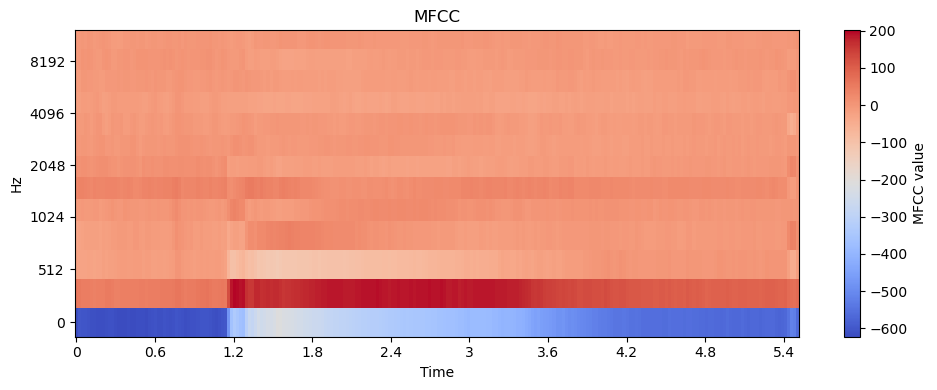

In [49]:
plt.figure(figsize=(10, 4))
librosa.display.specshow(mfcc, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(label='MFCC value')
plt.title('MFCC')
plt.tight_layout()
plt.show()

Dataset Class. Label is the directory where the wav file exists

In [51]:
class ChordDataset(Dataset):
    def __init__(self, chord_root_dir, sr=22050, n_mfcc=13, max_len=238):
        self.sr = sr
        self.n_mfcc = n_mfcc
        self.max_len = max_len
        self.file_paths = []  # was chord_files, but you reference file_paths later
        self.labels = []

        for folder in os.listdir(chord_root_dir):
            folder_path = os.path.join(chord_root_dir, folder)  # was root_dir
            if os.path.isdir(folder_path):
                for file in os.listdir(folder_path):
                    if file.endswith('.wav'):
                        self.file_paths.append(os.path.join(folder_path, file))
                        label = file.split('_')[0]
                        self.labels.append(label)

        # Map string labels to integers
        unique_labels = sorted(set(self.labels))
        self.label_to_index = {label: i for i, label in enumerate(unique_labels)}
        self.num_classes = len(unique_labels)
        self.labels = [self.label_to_index[l] for l in self.labels]

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        signal, _ = librosa.load(self.file_paths[idx], sr=self.sr)
        mfcc = librosa.feature.mfcc(y=signal, sr=self.sr, n_mfcc=self.n_mfcc)

        # Pad or truncate to fixed length
        if mfcc.shape[1] < self.max_len:
            pad_width = self.max_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :self.max_len]

        mfcc_tensor = torch.tensor(mfcc, dtype=torch.float32).unsqueeze(0)
        mfcc_label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mfcc_tensor, mfcc_label